# Greek Analysis

"Greeks" measure how sensitive a derivative's price is to changes in market conditions. Mathematically, they are the partial derivatives of the option's value function (like the one obtained from Black-Scholes-Merton model) with respect to variables such as the underlying asset price, time, volatility, and interest rates. For traders and risk managers, the Greeks are essential because they break down complex portfolio risk into clear, separate parts. This allows them to set up precise dynamic hedging strategies, such as maintaining a delta-neutral or vega-neutral position.

This notebook explores the risk profiles of standard European Call and Put options. Using our vectorized Black-Scholes-Merton pricing engine, we compute the main first- and second-order Greeks ($\Delta, \Gamma, \mathcal{V}, \Theta, \rho$). We then visualize how each Greek behaves across a range of spot prices to see the impact of moneyness, and observe how these risks change as the time to expiration drops from one year down to a single week.

## Import Python Libraries

In [25]:
import sys
sys.path.append('..')

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from datetime import date, timedelta
from dataclasses import replace

## Import Necessary Objects from My Option Pricing Library

In [17]:
from instruments.european import EuropeanOption

from core.enums import OptionType

from market.environment import MarketEnvironment

from engines.black_scholes_merton import BlackScholesMertonPricer
from engines.binomial_tree import BinomialTreePricer
from engines.monte_carlo import MonteCarloPricer

---

## Compute Greeks

The code below performs a vectorized computation of Black-Scholes-Merton Greeks across an array of spot prices for various times to expiry (from 1 week to 1 year). To ensure computational efficiency and avoid redundant calculations during visualization, the resulting `Greeks` objects are stored in a nested dictionary structured by maturity and option type (e.g., `{'1 Year': {'call': Greeks(...), 'put': Greeks(...)}}`). The stored Greeks are then dynamically accessed by the plotting functions in the subsequent sections.

In [18]:
# Option & Market parameters
strike = 100
time_to_expiry = [
    timedelta(days=365), 
    timedelta(days=182), 
    timedelta(days=91), 
    timedelta(days=30), 
    timedelta(days=7)
]
labels = ['1 Year', '6 Months', '3 Months', '1 Month', '1 Week']

spot_array = np.linspace(strike - 0.5*strike, strike + 0.5*strike, 200)
r = 0.10
vol = 0.40
q = 0.05
t = date(2026, 3, 18)

market = MarketEnvironment(
    spot_price=spot_array, 
    risk_free_rate=r, 
    volatility=vol, 
    dividend_yield=q, 
    pricing_date=t
)

bsm_engine = BlackScholesMertonPricer()

# --- COMPUTE AND STORE RESULTS ---
# Dictionary to store precomputed Greeks 
computed_greeks = {}

for T, label in zip(time_to_expiry, labels):
    eu_call = EuropeanOption(strike_price=strike, expiry_date=market.pricing_date + T, option_type=OptionType.CALL)
    eu_put = EuropeanOption(strike_price=strike, expiry_date=market.pricing_date + T, option_type=OptionType.PUT)
    
    # Calculate once per maturity and store in the dictionary
    computed_greeks[label] = {
        'call': eu_call.greeks(pricer=bsm_engine, market_env=market),
        'put': eu_put.greeks(pricer=bsm_engine, market_env=market)
    }

### Helper function for the plots

In [19]:
def plot_greek_vs_spot(greek_attribute: str, y_label_name: str):
    """
    Generates a standardized side-by-side plot for Call and Put Greeks.
    greek_attribute: the exact name of the attribute in the Greeks dataclass (e.g., 'delta', 'gamma')
    y_label_name: the formatted string for the chart titles and Y-axis (e.g., 'Delta', 'Gamma')
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    colors = cm.viridis(np.linspace(0.1, 0.9, len(labels)))
    
    for label, color in zip(labels, colors):
        # Retrieve cached data
        call_greeks_obj = computed_greeks[label]['call']
        put_greeks_obj = computed_greeks[label]['put']
        
        # Dynamically extract the specific Greek array (e.g., call_greeks_obj.delta)
        call_y = getattr(call_greeks_obj, greek_attribute)
        put_y = getattr(put_greeks_obj, greek_attribute)
        
        # Plot lines
        ax1.plot(spot_array, call_y, color=color, linewidth=2, label=label)
        ax2.plot(spot_array, put_y, color=color, linewidth=2, label=label)

    # --- Format Call Subplot (ax1) ---
    ax1.set_title(f'Call Option {y_label_name} vs. Spot Price', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Spot Price', fontsize=12)
    ax1.set_ylabel(y_label_name, fontsize=12)
    ax1.axvline(x=strike, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(title='Time to Expiry', frameon=True, shadow=True)

    # --- Format Put Subplot (ax2) ---
    ax2.set_title(f'Put Option {y_label_name} vs. Spot Price', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Spot Price', fontsize=12)
    ax2.set_ylabel(y_label_name, fontsize=12)
    ax2.axvline(x=strike, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(title='Time to Expiry', frameon=True, shadow=True)

    # Global Styling
    fig.patch.set_facecolor('#f8f9fa')
    ax1.set_facecolor('#ffffff')
    ax2.set_facecolor('#ffffff')

    plt.tight_layout()
    plt.show()

## 1. Delta ($\Delta$) vs Spot Price

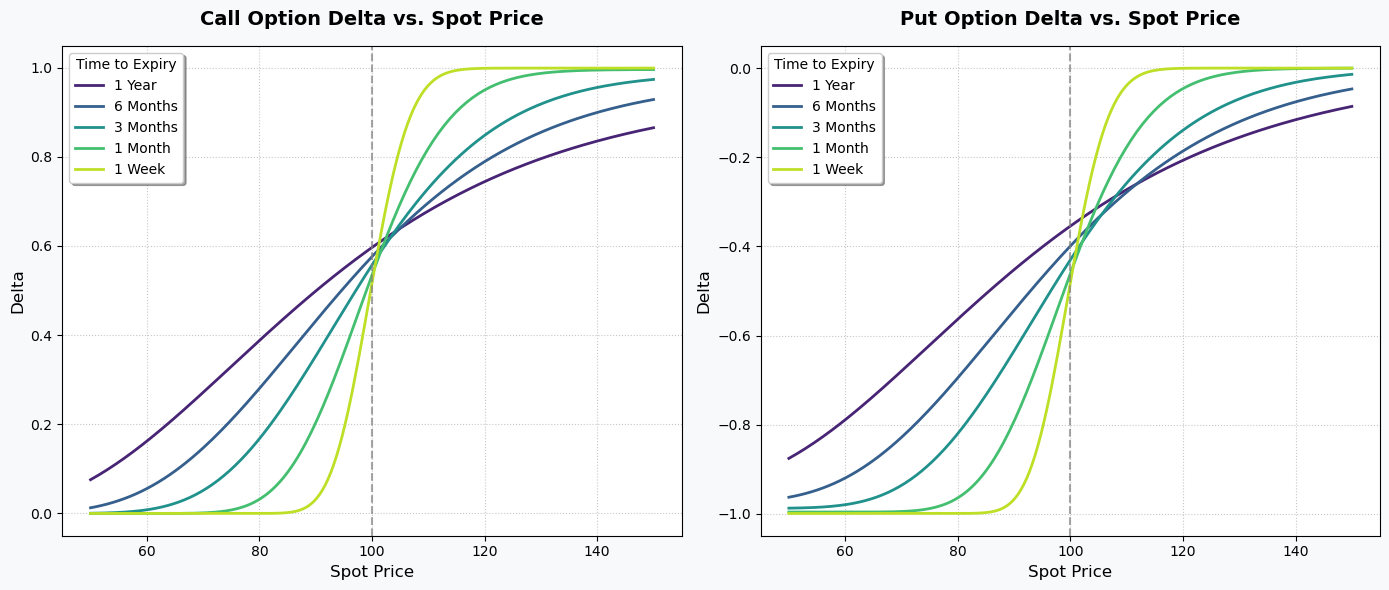

In [20]:
plot_greek_vs_spot(greek_attribute='delta', y_label_name='Delta')

### Delta ($\Delta$): Directional Risk and the Hedge Ratio

Delta is the first derivative of the option's price with respect to the underlying spot price. Simply put, it tells us how much the option's price is expected to change if the underlying stock moves by $1. For call options, Delta ranges from 0 to 1, while for put options, it ranges from -1 to 0. It is also commonly interpreted as the approximate probability that the option will expire in-the-money (ITM).

The curves naturally form an S-shape (a sigmoid curve) based on the option's moneyness:
*   **Deep Out-of-the-Money (OTM):** The option is very unlikely to pay off. Its price barely reacts to small movements in the underlying, so Delta approaches 0.
*   **Deep In-the-Money (ITM):** The option is almost certain to pay off. It begins to behave exactly like holding the underlying stock itself, so Delta flattens out at 1 (for calls) or -1 (for puts).
*   **At-the-Money (ATM):** This is where uncertainty is the highest, and the option is most sensitive to shifts in the stock price. 

**The impact of time to expiry**:
The shape of the curve changes dramatically as we get closer to expiration. The 1-Year line (dark purple) is smooth and gradual because there is still plenty of time for the stock to move — uncertainty is high across a wide range of prices. However, looking at the 1-Week line (lime green), the curve becomes extremely steep around the strike price. As time runs out, the option's fate becomes binary: it will either expire worthless (Delta = 0) or act as pure intrinsic value (Delta = 1). The transition zone between these two states becomes incredibly narrow.

**How traders use it (Delta hedging)**:
On a trading desk, Delta is primarily used as a **hedge ratio**. If a market maker sells 100 call options with a Delta of 0.60, their portfolio behaves as if they are short 60 shares of the stock. To neutralize this directional risk and become "delta-neutral," the trader simply buys 60 shares of the underlying asset. Because Delta changes as the stock price moves (which is measured with Gamma), the trader has to continuously adjust their stock position to stay hedged, a process known as dynamic hedging.

---

## 2. Gamma ($\Gamma$) vs Spot Price

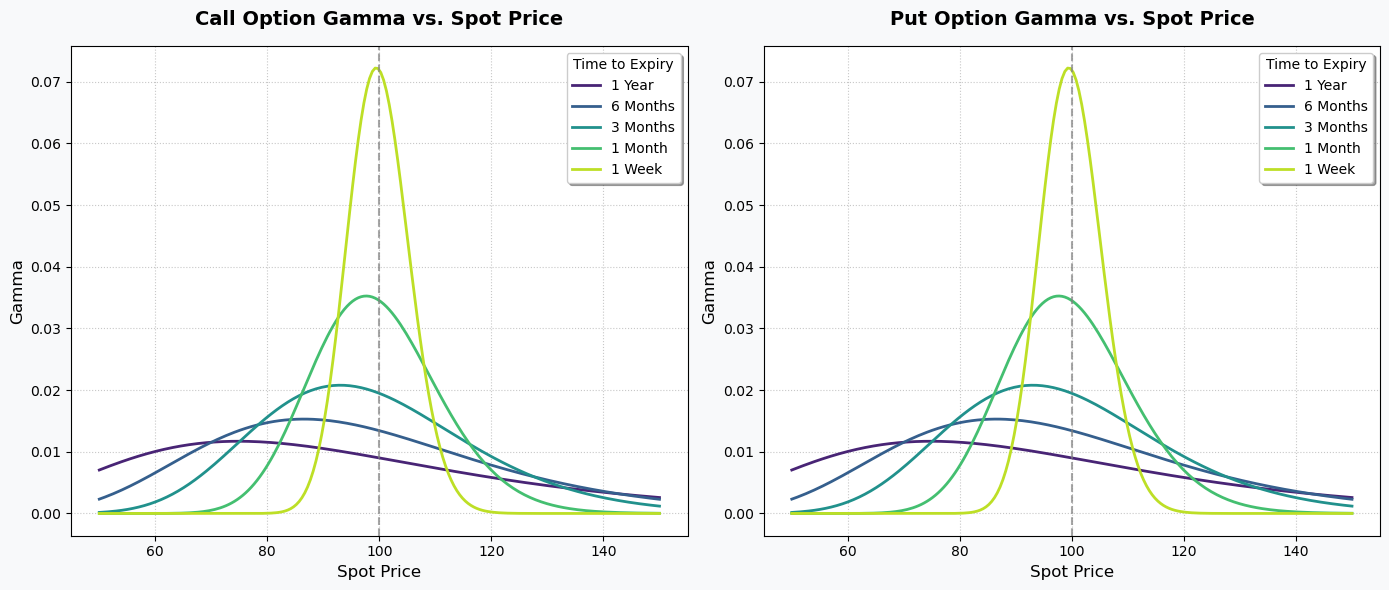

In [21]:
plot_greek_vs_spot(greek_attribute='gamma', y_label_name='Gamma')

### Gamma ($\Gamma$): Convexity and Rebalancing Risk

Gamma is the rate of change of Delta with respect to the underlying spot price. It represents the second partial derivative of the option's price with respect to the underlying asset. In practical terms, it measures how much the option's Delta will shift for a $1 movement in the stock price, quantifying the convexity of the option's value.

Gamma forms a bell-shaped curve that peaks near the At-The-Money (ATM) point, where uncertainty regarding the option's moneyness at expiration is highest. As expiration approaches, the shape of this curve changes dramatically. For a 1-Year option, Gamma is broad and flat, indicating that Delta changes smoothly and gradually across a wide range of spot prices. For a 1-Week option, the curve becomes highly concentrated and narrow. Because the short-dated Delta rapidly transitions from 0 to 1 around the strike price (or from -1 to 0), the rate of change (Gamma) exhibits a pronounced peak within that narrow price interval.

**Why it matters (Delta hedging)**:
For traders, Gamma represents the instability of a hedge. If a portfolio is delta-hedged, a high Gamma indicates that the portfolio's Delta will change rapidly with even minor movements in the underlying stock. To maintain a delta-neutral position, the trader is forced to frequently buy and sell the underlying asset to readjust the hedge ratio. This constant rebalancing incurs heavy transaction costs. Consequently, risk managers carefully monitor Gamma, knowing that short-dated ATM options carry substantial rebalancing risk.

---

## 3. Vega ($\mathcal{V}$)

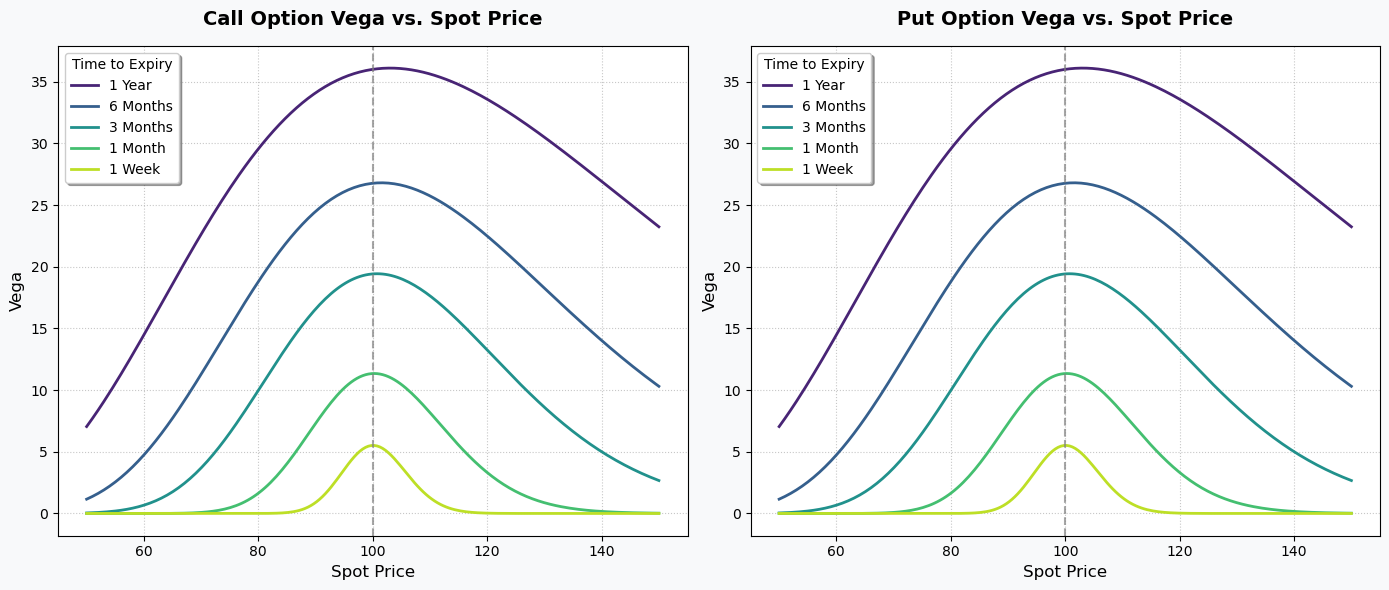

In [22]:
plot_greek_vs_spot(greek_attribute='vega', y_label_name='Vega')

### Vega ($\mathcal{V}$): Volatility Risk

Vega measures the sensitivity of the option's price to changes in the volatility of the underlying asset. It represents the first partial derivative of the option's value with respect to the annualized standard deviation of the asset's returns. Vega quantifies how much the option's price will change for a 1% (0.01) absolute change in implied volatility.

Vega follows a bell-shaped distribution that peaks near the At-The-Money (ATM) point. Options with strikes near the current spot price possess the highest amount of time value, making them the most sensitive to shifts in volatility. Because an ATM option has zero intrinsic value, its premium consists entirely of time value. This time value captures the expected benefit of the option's asymmetry: unlimited upside potential with downside strictly capped at zero. An increase in implied volatility widens the distribution of possible stock prices at expiration.
For an ATM option, the stock is sitting exactly at the strike price. A wider distribution significantly increases the potential for large profitable moves, and since losses are floored at zero, this extra variance translates directly into a higher expected payoff. This makes ATM options the most sensitive to volatility shifts (highest Vega).
Conversely, for deep OTM options, the stock is so far from the strike that even with a wider distribution, the odds of a payout remain extremely small. For deep ITM options, the contract is already so deep in the profitable zone that it behaves almost linearly, like owning the stock itself; the wider distribution creates extra upside and extra downside that effectively cancel each other out in expectation, since the zero-payoff floor is too far away to provide meaningful protection. As a result, Vega decays toward zero the further an option moves deep ITM or OTM.

The magnitude of Vega is also heavily influenced by the time to maturity. As the charts illustrate, long-dated options (e.g., 1 Year) have much higher Vega than short-dated options (e.g., 1 Week). This relationship exists because a longer time horizon provides more opportunity for volatility to impact the final distribution of the stock price. Conversely, as expiration approaches, the "optionality" of the contract diminishes, and the impact of volatility on the option's price shrinks toward zero.

**Why it matters (Vega hedging)**:
Traders use Vega to manage "volatility risk." A portfolio with a high positive Vega will gain value if implied volatility rises but will suffer losses if volatility falls (often called "vol crush"). To neutralize this risk, traders can enter offsetting positions in other options to achieve a vega-neutral state. This is particularly important around earnings announcements or major economic events where implied volatility tends to fluctuate rapidly.

---

## 4. Theta ($\Theta$) vs Spot Price

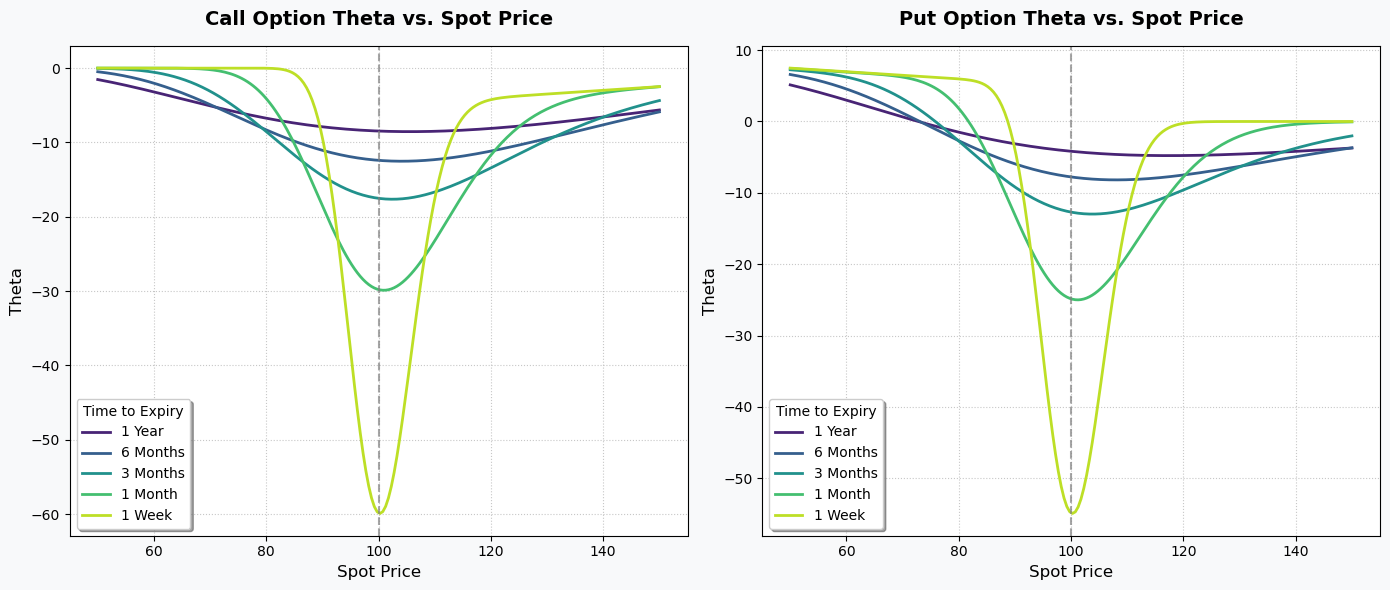

In [23]:
plot_greek_vs_spot(greek_attribute='theta', y_label_name='Theta')

### Theta ($\Theta$): Time Decay

Theta measures how much an option's price changes as time passes. It is often called "time decay". It represents the daily loss in the option's value, assuming the stock price and volatility do not move. If our theta is -5.0, that means the option loses \\$5.00 per year, or roughly \\$5.00/365 $\approx$ \\$0.0137 per day. 

*Note: The Theta values shown in this notebook are annualized. To obtain the daily time decay commonly quoted by traders, divide by 365.*

For someone who has bought an option, Theta is usually negative. This is because options have a fixed expiration date. Part of an option’s price is based on the "optionality" — the possibility that the underlying price will move favorably before expiration. As each day passes, there is less time left for the stock to move, so that possibility becomes less valuable. If the stock stays at the same price, the option will naturally lose value as it gets closer to expiration.

As seen in the charts, Theta is most extreme for At-The-Money (ATM) options (where the spot price is near the strike). These options have the highest "time value" because their outcome is the most uncertain. 
*   **1-Year Option:** Time decay is slow and steady because there is still a long time for the stock to move.
*   **1-Week Option:** Time decay accelerates dramatically. Because the option is about to expire, it loses its remaining time value very quickly, creating the deep "V" shape in the chart at the strike price.

Theta in the Put chart becomes positive for options that are deep In-The-Money (when the spot price is much lower than the strike). This happens because a deep ITM put is almost certain to pay out the strike price at expiration, acting essentially like a guaranteed future cash flow. Since future cash flows are discounted to their present value based on interest rates, as calendar time moves forward, the remaining wait time until expiration shrinks. Because the strike price is discounted over a shorter and shorter period, its present value actually increases with each passing day. When this steady upward pull in the present value (the unwinding of the interest rate discount) outweighs the loss of whatever tiny amount of "optionality" (time value) is left, the option's total price goes up as time passes, resulting in a positive Theta.

**Why Theta matters**: 
Owning an option is a trade-off. The buyer of an option gains the potential for a large profit or protection against a crash, but they "pay" for this daily through time decay. On the other side, the person who sold the option takes on the risk of the stock moving against them, but they are compensated by the daily increase in value as the option's expiration date approaches.

---

## 5. Rho ($\rho$) vs Spot Price

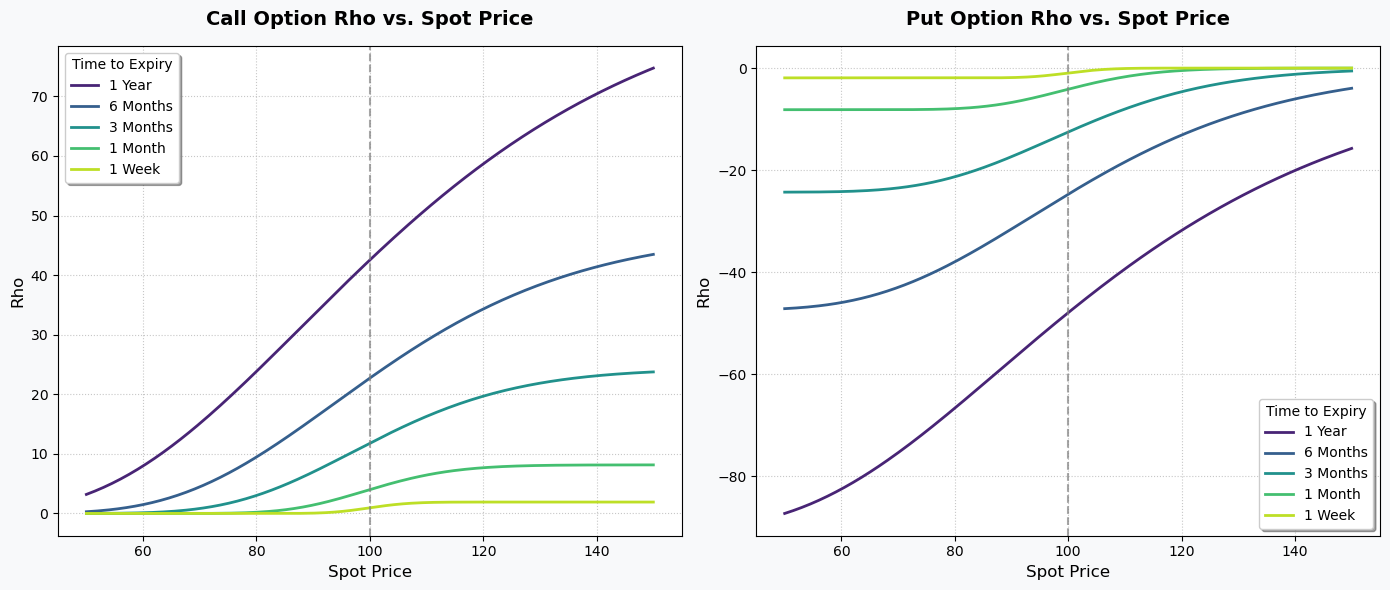

In [24]:
plot_greek_vs_spot(greek_attribute='rho', y_label_name='Rho')

### Rho ($\rho$): Interest Rate Risk

Rho measures the sensitivity of an option's price to changes in the risk-free interest rate. Mathematically, it is the first partial derivative of the option's value with respect to the interest rate ($r$). It quantifies the expected absolute change in the option's premium for a 1% (0.01) change in the risk-free rate.

The sign of Rho is determined by the present value of the strike price ($K$). 
For a Call option, the holder possesses the right to purchase the underlying asset by paying the strike price at expiration. Higher interest rates decrease the present value of this future cash outflow. Because the liability becomes "cheaper" in today's terms, the value of the Call option increases, resulting in a positive Rho. 

Conversely, for a Put option, the holder has the right to sell the underlying asset and receive the strike price as cash at expiration. Higher interest rates decrease the present value of this future cash inflow. Because the expected payout is worth less in today's terms, the value of the Put option decreases, resulting in a negative Rho.

Rho is maximized in absolute terms for deep In-The-Money (ITM) options. For a deep ITM option, the probability of exercise approaches 100%, meaning the future exchange of the strike cash is almost certain. As a result, the option's premium becomes highly sensitive to the discount rate applied to that strike price. Out-of-the-Money (OTM) options carry a very low probability of exercise, rendering the present value of the strike price mathematically irrelevant and driving Rho toward zero.

Furthermore, the magnitude of Rho scales proportionally with the time to expiration. Long-dated options (e.g., 1 Year) are subject to a prolonged discounting period, making them highly sensitive to interest rate shifts. Short-dated options (e.g., 1 Week) face virtually no discounting effect, resulting in a flat Rho curve that remains near zero across all spot prices.

---

## Comparison: BSM vs Numerical Greeks

To demonstrate that our finite difference implementation of Greeks computation matches the closed-form BSM Greeks, we compute Greeks using Binomial Tree and Monte Carlo engines and compare them against analytical Greeks.

In [44]:
# Compute Greeks numerically - Binomial Tree and Monte Carlo - "bump and reprice" method
num_tree_steps = 100 # choose the number of time steps in the Binomial Tree
num_paths_mc = 100000 # choose the number of paths for Monte Carlo
seed = 42 # set random seed for reproducibility

i = 0 # index for time to expiry, we will use 1 year
T = time_to_expiry[i] # for i=0 corresponds to 1 year to expiry
label = labels[i]

binom_engine = BinomialTreePricer(num_tree_steps = num_tree_steps)
mc_engine = MonteCarloPricer(num_paths = num_paths_mc, random_seed = seed)

option = EuropeanOption(strike_price=strike, expiry_date=market.pricing_date + T, option_type=OptionType.CALL) # market is defined above

bsm_greeks = computed_greeks # computed above

binom_greeks = {}
mc_greeks = {}
binom_greeks[label] = {
    option.option_type.value : {
        'delta' : [],
        'gamma' : [],
        'vega' : [],
        'theta' : [],
        'rho' : []
    }
}

mc_greeks[label] = {
    option.option_type.value : {
        'delta' : [],
        'gamma' : [],
        'vega' : [],
        'theta' : [],
        'rho' : []
    }
}
greeks = ['delta', 'gamma', 'vega', 'theta', 'rho']
for spot in spot_array:
    market_scalar = replace(market, spot_price=spot)

    binom_greeks_obj = option.greeks(pricer=binom_engine, market_env=market_scalar)
    mc_greeks_obj = option.greeks(pricer=mc_engine, market_env=market_scalar)

    for greek in greeks:
        # Binomial Greeks
        greek_value_binom = getattr(binom_greeks_obj, greek)
        binom_greeks[label][option.option_type.value][greek].append(greek_value_binom)

        # Monte Carlo Greeks
        greek_value_mc = getattr(mc_greeks_obj, greek)
        mc_greeks[label][option.option_type.value][greek].append(greek_value_mc)

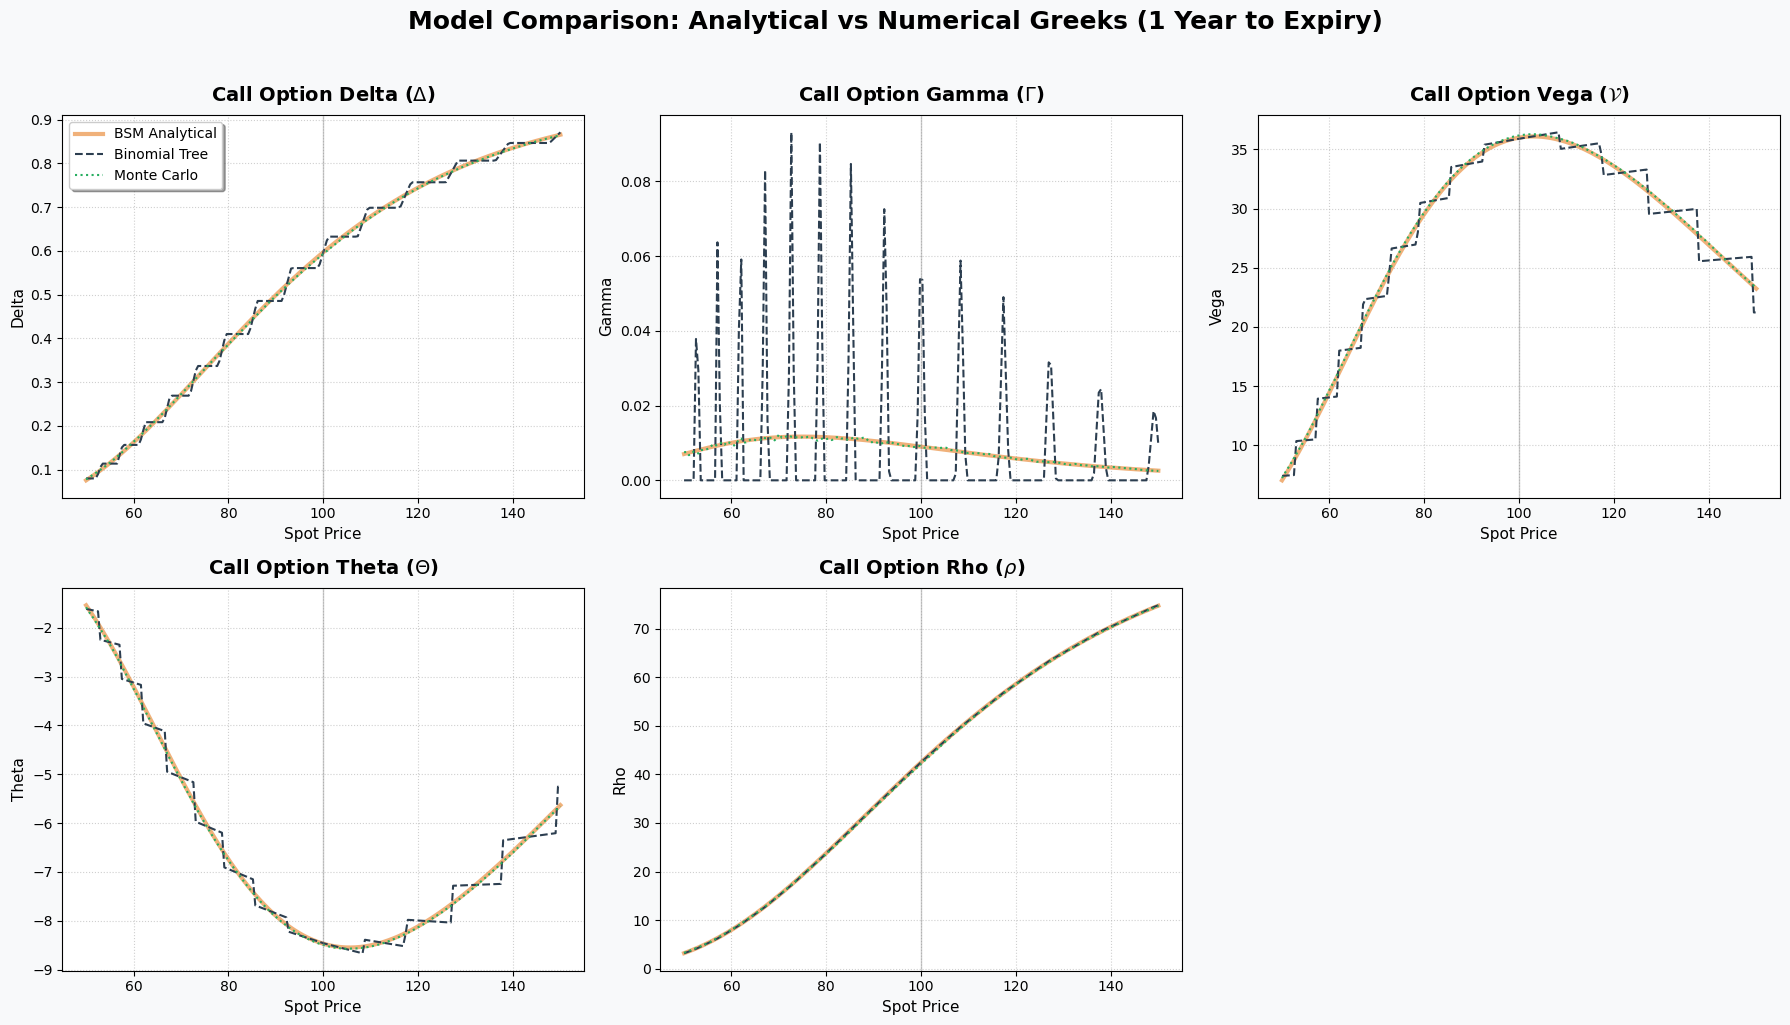

In [43]:
# Plot the Analytical vs Numerical Greeks
greeks_list = ['delta', 'gamma', 'vega', 'theta', 'rho']
greek_titles = [
    r'Delta ($\Delta$)', 
    r'Gamma ($\Gamma$)', 
    r'Vega ($\mathcal{V}$)', 
    r'Theta ($\Theta$)', 
    r'Rho ($\rho$)'
]

# Create a 2x3 dashboard (then hide the 6th empty subplot)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 matrix into a 1D array of 6 axes for easy looping

opt_type = option.option_type.value

for idx, greek in enumerate(greeks_list):
    ax = axes[idx]
    
    # Extract the data
    bsm_y = getattr(bsm_greeks[label][opt_type], greek)
    binom_y = binom_greeks[label][opt_type][greek]
    mc_y = mc_greeks[label][opt_type][greek]
    
    # 1. BSM Analytical (Thick solid line in the background)
    ax.plot(spot_array, bsm_y, color='#e67e22', linewidth=3, alpha=0.6, label='BSM Analytical')
    
    # 2. Binomial Tree (Dashed line)
    ax.plot(spot_array, binom_y, color='#2c3e50', linestyle='--', linewidth=1.5, label='Binomial Tree')
    
    # 3. Monte Carlo (Dotted line with markers to show variance)
    ax.plot(spot_array, mc_y, color='#27ae60', linestyle=':', linewidth=1.5, label='Monte Carlo')
    
    # Formatting
    ax.set_title(f'Call Option {greek_titles[idx]}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Spot Price', fontsize=11)
    ax.set_ylabel(greek.capitalize(), fontsize=11)
    ax.axvline(x=strike, color='gray', linestyle='-', linewidth=1, alpha=0.4) # ATM Line
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if idx == 0: # Only put the legend on the first chart to avoid clutter
        ax.legend(frameon=True, shadow=True, facecolor='white', loc='best')

# Hide the 6th empty subplot (since we only have 5 Greeks)
fig.delaxes(axes[5])

# Global Styling
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(f'Model Comparison: Analytical vs Numerical Greeks ({label} to Expiry)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The dashboard above overlays the Greeks generated by our three pricing engines. The continuous Black-Scholes-Merton (BSM) model provides the smooth, analytical benchmark.

Applying finite-difference methods ("bump and reprice") to the numerical engines clearly visualizes their structural limitations:

1. **Tree Jaggedness (The Sawtooth Effect):** The Binomial Tree exhibits severe oscillations, particularly in Gamma. Because the tree maps continuous spot prices onto a discrete, $N$-step lattice, bumping the spot price causes the terminal nodes to shift irregularly across the non-linear strike boundary. This discrete shifting translates into step-like structures for first-order Greeks and massive instability for second-order Greeks (Gamma). Increasing the number of tree steps would smooth the curve but at computational cost.
2. **Monte Carlo Variance:** The Monte Carlo Greeks track the analytical benchmark well but exhibit statistical noise. Calculating sensitivities via finite differences on simulated paths inherently magnifies the standard error of the simulation, visualizing the classic trade-off between computational speed and gradient stability.

This comparison serves as a critical **validation step** for the library. By overlaying the numerical results onto the analytical Black-Scholes-Merton (BSM) curves, we can confirm that the general finite-difference logic implemented in the `BasePricer` is mathematically sound. Even with the inherent limitations of numerical models, the fact that the "staircases" and "noise" center perfectly around the BSM benchmark shows that the implementation is correct which is important considering its use for option Greeks that do not have analytical solutions, such as Greeks of path-dependent or American options.

---

## Conclusion

The analysis in this notebook demonstrates that each Greek follows a characteristic moneyness profile that evolves predictably as the time to expiration decreases. As maturity approaches, risk sensitivities become increasingly concentrated near the strike price, resulting in the sharp peaks and steep slopes observed in the short-dated curves. Finally, the strong alignment between the numerical and analytical Greek results validates the library's implementation of both the closed-form Black-Scholes-Merton formulas and the general finite-difference logic.